## 1. Install + Imports

In [ ]:
!pip install -q sentencepiece optuna scikit-learn==1.5.* --upgrade


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, gc, math, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    TrainerCallback,
    set_seed,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    mean_absolute_error, cohen_kappa_score, confusion_matrix,
)
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

/home/mabdrabou/.pyenv/versions/3.10.13/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.9.0+cu128).


Device: cuda
GPU: Quadro RTX 8000
VRAM: 50.8 GB


## 2. Load + Clean Data

In [3]:
df = pd.read_excel('/home/mabdrabou/Desktop/NLP Project/Fine Tuning/NLP_qwen_labels_output.xlsx')
print(f'Loaded: {len(df)} rows')
print(df.isna().sum())
df.head(3)

Loaded: 27977 rows
text                        2
label                       0
qwen_score                  0
Qwen_Labels                 0
qwen_rating                 0
qwen_reasoning              0
qwen_dominant_signals    1166
dtype: int64


,text,label,qwen_score,Qwen_Labels,qwen_rating,qwen_reasoning,qwen_dominant_signals
0,dear american teens question dutch person hear...,0,1,{'reasoning': 'The text contains no emotional ...,BEST,The text contains no emotional content or dist...,"neutral communication, educational inquiry, no..."
1,nothing look forward lifei dont many reasons k...,1,9,"{'reasoning': ""The text explicitly states suic...",VERY_VERY_BAD,The text explicitly states suicidal ideation (...,"suicidal ideation, hopelessness, no future ori..."
2,music recommendations im looking expand playli...,0,2,{'reasoning': 'The text focuses solely on requ...,VERY_GOOD,The text focuses solely on requesting music re...,"music interest, genre exploration, social enga..."


In [ ]:
df = df.dropna(subset=['text', 'label', 'qwen_score', 'qwen_rating']).reset_index(drop=True)

df = df.drop(columns=[c for c in ['qwen_reasoning', 'qwen_dominant_signals', 'Qwen_Labels']
                      if c in df.columns])

contradictory = (
    ((df['label'] == 1) & (df['qwen_score'] <= 5)) |
    ((df['label'] == 0) & (df['qwen_score'] >= 6))
)
print(f'Contradictory rows dropped: {contradictory.sum()}')
df = df[~contradictory].reset_index(drop=True)

df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() >= 3].reset_index(drop=True)

df['class_label'] = df['qwen_score'].astype(int) - 1

print(f'\nFinal dataset: {len(df)} rows')
print(df.shape)

Contradictory rows dropped: 2

Final dataset: 27972 rows
(27972, 5)


In [5]:
RATING_NAMES = ['BEST', 'VERY_GOOD', 'GOOD', 'MODERATE_GOOD', 'NEUTRAL',
                'MODERATE_BAD', 'BAD', 'VERY_BAD', 'VERY_VERY_BAD', 'WORST']

dist = df['class_label'].value_counts().sort_index()
print('=== Class distribution (using ALL data, not downsampled) ===')
for i, name in enumerate(RATING_NAMES):
    count = dist.get(i, 0)
    pct = 100 * count / len(df)
    print(f'{i+1:2d} {name:<14} {count:>5}  ({pct:>5.1f}%)')

=== Class distribution (using ALL data, not downsampled) ===
 1 BEST            6493  ( 23.2%)
 2 VERY_GOOD       2380  (  8.5%)
 3 GOOD            1162  (  4.2%)
 4 MODERATE_GOOD   3065  ( 11.0%)
 5 NEUTRAL         1037  (  3.7%)
 6 MODERATE_BAD    2067  (  7.4%)
 7 BAD              880  (  3.1%)
 8 VERY_BAD        1008  (  3.6%)
 9 VERY_VERY_BAD   8055  ( 28.8%)
10 WORST           1825  (  6.5%)


## 3. Config

In [ ]:
MODEL_NAME   = 'microsoft/deberta-v3-large'

NUM_LABELS   = 10
MAX_LENGTH   = 512
STRIDE       = 128            
BATCH_SIZE   = 16              
GRAD_ACCUM   = 1
EPOCHS       = 6               
LR           = 8e-6                           
WEIGHT_DECAY = 0.05            
WARMUP_RATIO = 0.1
LABEL_SMOOTH = 0.1             
LLRD         = 0.9           
PATIENCE     = 2               
DROPOUT      = 0.2             

OUTPUT_DIR   = './deberta_large_severity2' 

## 4. Stratified Train/Val/Test Split 

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df['class_label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['class_label']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(NUM_LABELS),
    y=train_df['class_label'].values,
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print('\nClass weights:')
for i, (name, w) in enumerate(zip(RATING_NAMES, class_weights.cpu().numpy())):
    print(f'  {i+1:2d} {name:<14} {w:.3f}')

Train: 22377 | Val: 2797 | Test: 2798

Class weights:
   1 BEST           0.431
   2 VERY_GOOD      1.175
   3 GOOD           2.406
   4 MODERATE_GOOD  0.913
   5 NEUTRAL        2.696
   6 MODERATE_BAD   1.354
   7 BAD            3.179
   8 VERY_BAD       2.776
   9 VERY_VERY_BAD  0.347
  10 WORST          1.533


## 5. Tokenize with Sliding Window (no truncation of long texts)

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_sliding(texts, labels, name=''):
    """Long texts are split into overlapping chunks; each chunk inherits the parent label.
    `sample_ids` maps each chunk back to its parent row so we can aggregate at test time."""
    ids, masks, lbls, sids = [], [], [], []
    long_count = 0
    for idx, (t, y) in enumerate(tqdm(list(zip(texts, labels)), desc=f'Tokenize [{name}]')):
        enc = tokenizer(
            str(t),
            max_length=MAX_LENGTH,
            stride=STRIDE,
            truncation=True,
            padding='max_length',
            return_overflowing_tokens=True,
            return_tensors='pt',
        )
        n = enc['input_ids'].shape[0]
        if n > 1: long_count += 1
        for i in range(n):
            ids.append(enc['input_ids'][i])
            masks.append(enc['attention_mask'][i])
            lbls.append(int(y))
            sids.append(idx)
    print(f'  [{name}] {len(texts)} texts -> {len(lbls)} chunks ({long_count} long)')
    return ids, masks, lbls, sids

train_ids, train_masks, train_lbls, _          = preprocess_sliding(train_df['text'].values, train_df['class_label'].values, 'train')
val_ids,   val_masks,   val_lbls,   val_sids   = preprocess_sliding(val_df['text'].values,   val_df['class_label'].values,   'val')
test_ids,  test_masks,  test_lbls,  test_sids  = preprocess_sliding(test_df['text'].values,  test_df['class_label'].values,  'test')

Tokenize [train]: 100%|██████████| 22377/22377 [00:12<00:00, 1746.16it/s]


  [train] 22377 texts -> 22699 chunks (246 long)


Tokenize [val]: 100%|██████████| 2797/2797 [00:01<00:00, 1699.39it/s]


  [val] 2797 texts -> 2832 chunks (30 long)


Tokenize [test]: 100%|██████████| 2798/2798 [00:01<00:00, 1640.00it/s]

  [test] 2798 texts -> 2852 chunks (25 long)


In [9]:
class ChunkedDataset(Dataset):
    def __init__(self, ids, masks, labels):
        self.ids = ids; self.masks = masks; self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return {
            'input_ids':      self.ids[i],
            'attention_mask': self.masks[i],
            'labels':         torch.tensor(self.labels[i], dtype=torch.long),
        }

train_dataset = ChunkedDataset(train_ids, train_masks, train_lbls)
val_dataset   = ChunkedDataset(val_ids,   val_masks,   val_lbls)
test_dataset  = ChunkedDataset(test_ids,  test_masks,  test_lbls)

## 6. Model + Layer-wise LR Decay + Weighted-CE Trainer

In [ ]:
def build_model():
    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        hidden_dropout_prob=DROPOUT,
        attention_probs_dropout_prob=DROPOUT,
        ignore_mismatched_sizes=True,
    )
    m.config.use_cache = False
    m.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    return m

def get_layerwise_lr_params(model, base_lr=LR, decay=LLRD, weight_decay=WEIGHT_DECAY):

    no_decay = ('bias', 'LayerNorm.weight', 'LayerNorm.bias')
    params = []

    head_params = [(n, p) for n, p in model.named_parameters()
                   if 'classifier' in n or 'pooler' in n]
    params.append({
        'params':       [p for n, p in head_params if not any(nd in n for nd in no_decay)],
        'lr':           base_lr,
        'weight_decay': weight_decay,
    })
    params.append({
        'params':       [p for n, p in head_params if any(nd in n for nd in no_decay)],
        'lr':           base_lr,
        'weight_decay': 0.0,
    })
    layer_idx = 0
    while True:
        layer_params = [(n, p) for n, p in model.named_parameters()
                        if f'encoder.layer.{layer_idx}.' in n]
        if not layer_params:
            break
        lr_l = base_lr * (decay ** (12 - layer_idx))  
        params.append({
            'params':       [p for n, p in layer_params if not any(nd in n for nd in no_decay)],
            'lr':           lr_l,
            'weight_decay': weight_decay,
        })
        params.append({
            'params':       [p for n, p in layer_params if any(nd in n for nd in no_decay)],
            'lr':           lr_l,
            'weight_decay': 0.0,
        })
        layer_idx += 1

    emb_params = [(n, p) for n, p in model.named_parameters() if 'embeddings' in n]
    params.append({
        'params':       [p for n, p in emb_params if not any(nd in n for nd in no_decay)],
        'lr':           base_lr * (decay ** 13),
        'weight_decay': weight_decay,
    })
    params.append({
        'params':       [p for n, p in emb_params if any(nd in n for nd in no_decay)],
        'lr':           base_lr * (decay ** 13),
        'weight_decay': 0.0,
    })
    return params


In [11]:
class WeightedTrainer(Trainer):
    """Trainer with class-weighted cross-entropy + label smoothing.
    Two regularizers stacked: weights fight imbalance, smoothing fights noisy labels."""
    def __init__(self, class_weights=None, label_smoothing=0.0, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights
        self.label_smoothing = label_smoothing

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights,
            label_smoothing=self.label_smoothing,
        )
        loss = loss_fct(logits.view(-1, NUM_LABELS), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

## 7. Multi-Metric Evaluation

In [12]:
def to_bucket5(scores):
    """Collapse 10 classes into 5 buckets: 0=Healthy 1=Good 2=Neutral 3=Bad 4=Critical"""
    s = np.asarray(scores)
    out = np.zeros_like(s)
    out[(s >= 0) & (s <= 1)] = 0   # BEST, VERY_GOOD
    out[(s >= 2) & (s <= 3)] = 1   # GOOD, MODERATE_GOOD
    out[s == 4]              = 2   # NEUTRAL
    out[(s >= 5) & (s <= 7)] = 3   # MODERATE_BAD, BAD, VERY_BAD
    out[(s >= 8) & (s <= 9)] = 4   # VERY_VERY_BAD, WORST
    return out

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    off_by_one = np.mean(np.abs(preds - labels) <= 1)
    return {
        'accuracy':     accuracy_score(labels, preds),
        'f1_macro':     f1_score(labels, preds, average='macro'),
        'f1_weighted':  f1_score(labels, preds, average='weighted'),
        'off_by_one':   off_by_one,
        'mae':          mean_absolute_error(labels, preds),
        'qwk':          cohen_kappa_score(labels, preds, weights='quadratic'),
        'bucket5_acc':  accuracy_score(to_bucket5(labels), to_bucket5(preds)),
    }

## 8. Train

In [ ]:
model = build_model().to(device).float()  

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LR,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'qwk',    
    greater_is_better           = True,
    logging_steps               = 50,
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 2,
    report_to                   = 'none',
    lr_scheduler_type           = 'cosine',
)


from torch.optim import AdamW
optimizer = AdamW(get_layerwise_lr_params(model), lr=LR)

trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    optimizers      = (optimizer, None),   
    class_weights   = class_weights,
    label_smoothing = LABEL_SMOOTH,
)

trainer.train()

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Off By One,Mae,Qwk,Bucket5 Acc
1,1.849600,1.760601,0.470692,0.388813,0.500521,0.856285,0.801907,0.919396,0.760593
2,1.734400,1.739951,0.553319,0.468529,0.570420,0.859110,0.711864,0.927145,0.800494
3,1.649900,1.706385,0.555438,0.478700,0.577453,0.871116,0.683616,0.932165,0.807556
4,1.471600,1.700240,0.595339,0.518587,0.618405,0.888771,0.616525,0.939446,0.821681
5,1.297100,1.729385,0.598517,0.516930,0.622031,0.885240,0.611229,0.940595,0.815678
6,1.320300,1.734564,0.604167,0.517912,0.626228,0.885946,0.604873,0.941301,0.817797


TrainOutput(global_step=8514, training_loss=1.5967538272211579, metrics={'train_runtime': 23740.2928, 'train_samples_per_second': 5.737, 'train_steps_per_second': 0.359, 'total_flos': 1.269277477369897e+17, 'train_loss': 1.5967538272211579, 'epoch': 6.0})

## 9. Final Evaluation on Test Set (with chunk aggregation)

In [ ]:
print('=== Predicting on test set ===')
raw_preds = trainer.predict(test_dataset)
chunk_logits = raw_preds.predictions   

n_samples = len(test_df)
agg_logits = np.zeros((n_samples, NUM_LABELS))
chunk_counts = np.zeros(n_samples)
for ci, sid in enumerate(test_sids):
    agg_logits[sid] += chunk_logits[ci]
    chunk_counts[sid] += 1
agg_logits /= chunk_counts[:, None]
final_preds = np.argmax(agg_logits, axis=-1)
true = test_df['class_label'].values

print('\n--- 10-class classification report ---')
print(classification_report(true, final_preds, target_names=RATING_NAMES, digits=3))

print('--- Ordinal & bucket metrics ---')
print(f'Exact accuracy (10-class):      {accuracy_score(true, final_preds):.4f}')
print(f'Off-by-one accuracy (within +-1): {np.mean(np.abs(final_preds - true) <= 1):.4f}')
print(f'5-bucket accuracy:              {accuracy_score(to_bucket5(true), to_bucket5(final_preds)):.4f}')
print(f'Mean Absolute Error (classes):  {mean_absolute_error(true, final_preds):.4f}')
print(f'Quadratic Weighted Kappa:       {cohen_kappa_score(true, final_preds, weights="quadratic"):.4f}')
print(f'F1 macro:                       {f1_score(true, final_preds, average="macro"):.4f}')
print(f'F1 weighted:                    {f1_score(true, final_preds, average="weighted"):.4f}')

print('\n--- 5-bucket classification report ---')
bucket_names = ['Healthy', 'Good', 'Neutral', 'Bad', 'Critical']
print(classification_report(to_bucket5(true), to_bucket5(final_preds),
                            target_names=bucket_names, digits=3))

=== Predicting on test set ===



--- 10-class classification report ---
               precision    recall  f1-score   support

         BEST      0.877     0.660     0.753       650
    VERY_GOOD      0.390     0.534     0.450       238
         GOOD      0.276     0.474     0.349       116
MODERATE_GOOD      0.648     0.629     0.638       307
      NEUTRAL      0.407     0.466     0.434       103
 MODERATE_BAD      0.647     0.585     0.614       207
          BAD      0.349     0.341     0.345        88
     VERY_BAD      0.301     0.436     0.356       101
VERY_VERY_BAD      0.881     0.733     0.800       806
        WORST      0.522     0.797     0.630       182

     accuracy                          0.637      2798
    macro avg      0.530     0.565     0.537      2798
 weighted avg      0.692     0.637     0.654      2798

--- Ordinal & bucket metrics ---
Exact accuracy (10-class):      0.6372
Off-by-one accuracy (within +-1): 0.8946
5-bucket accuracy:              0.8306
Mean Absolute Error (classes):  0.5

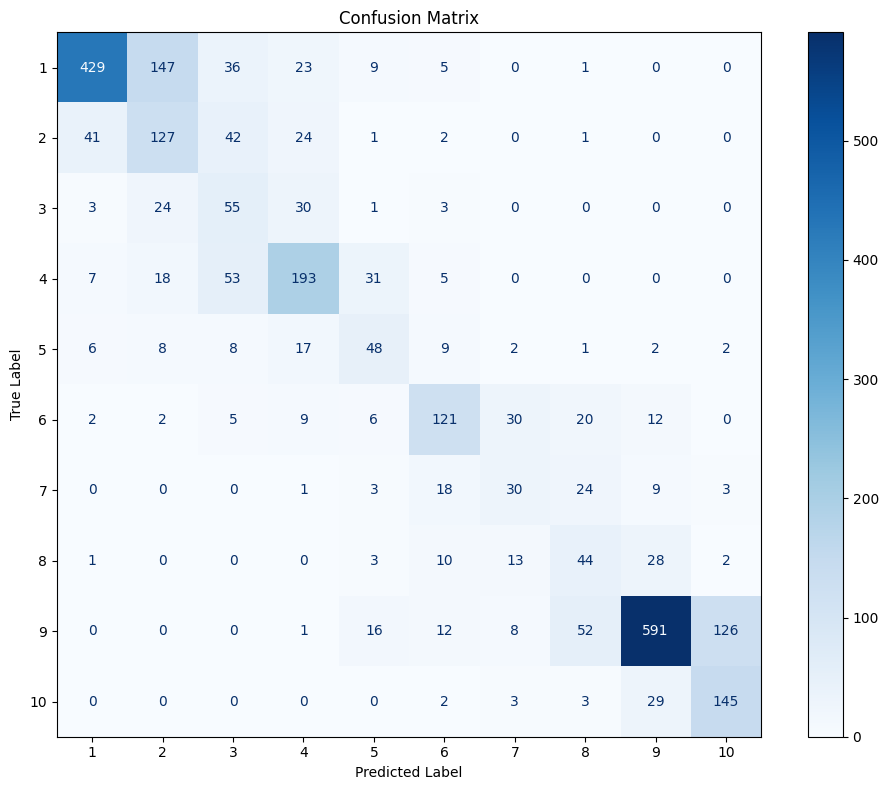

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true, final_preds)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[i+1 for i in range(10)])

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 10. Save Model

In [16]:
trainer.save_model(f'{OUTPUT_DIR}/best_model')
tokenizer.save_pretrained(f'{OUTPUT_DIR}/best_model')
print(f'Saved to {OUTPUT_DIR}/best_model')

Saved to ./deberta_large_severity2/best_model
